## AutoEncoder with TensorFlow - ML


Autoencoders are neural networks used for unsupervised learning tasks like dimensionality reduction, anomaly detection and feature extraction. They consist of two key parts:

* Encoder that compresses data into a compact form.
* Decoder that reconstructs the original data from this compressed representation.
The main goal is to minimize the difference between the input and its reconstruction. We'll implement a Convolutional Neural Network (CNN) based autoencoder using TensorFlow and the MNIST dataset.

## Implementing Autoencoders using TensorFlow

### Step 1: Importing libraries

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

### Step 2: Loading the Dataset

Now we load the MNIST dataset using tf.keras.datasets.mnist.load_data(). This dataset includes 60,000 training and 10,000 testing grayscale digit images of size 28×28 pixels

In [2]:
(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

### Step 3: Defining the Autoencoder

In [3]:
latent_dim = 32 

encoder_input = keras.Input(shape=(28, 28, 1))
x = layers.Conv2D(16, (3, 3), activation="relu", padding="same")(encoder_input)
x = layers.MaxPooling2D((2, 2), padding="same")(x)
x = layers.Conv2D(8, (3, 3), activation="relu", padding="same")(x)
x = layers.MaxPooling2D((2, 2), padding="same")(x)
x = layers.Conv2D(8, (3, 3), activation="relu", padding="same")(x)
encoded = layers.MaxPooling2D((2, 2), padding="same")(x)

x = layers.Conv2D(8, (3, 3), activation="relu", padding="same")(encoded)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(8, (3, 3), activation="relu", padding="same")(x)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(16, (3, 3), activation="relu")(x)
x = layers.UpSampling2D((2, 2))(x)
decoded = layers.Conv2D(1, (3, 3), activation="sigmoid", padding="same")(x)

### Step 4: Compiling and Training the Autoencoder

In [4]:
autoencoder = keras.Model(encoder_input, decoded)
autoencoder.compile(optimizer="adam", loss="binary_crossentropy")

autoencoder.fit(
    x_train, x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test, x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 33ms/step - loss: 0.2146 - val_loss: 0.1486
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - loss: 0.1364 - val_loss: 0.1263
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 28ms/step - loss: 0.1226 - val_loss: 0.1171
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 24s 36ms/step - loss: 0.1158 - val_loss: 0.1121
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - loss: 0.1115 - val_loss: 0.1087
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 19s 28ms/step - loss: 0.1084 - val_loss: 0.1057
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 32ms/step - loss: 0.1060 - val_loss: 0.1036
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 15s 31ms/step - loss: 0.1040 - val_loss: 0.1021
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 16s 33ms/step - loss: 0.1026 - val_loss: 0.1010
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - loss: 0.1013 - val_loss: 0.0997


### Step 5: Visualizing Original and Reconstructed Images

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step


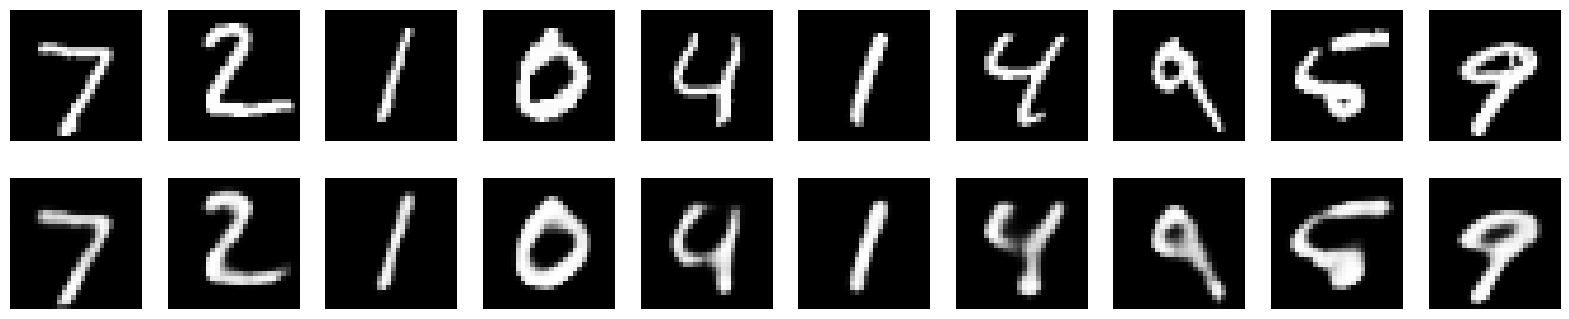

In [6]:
encoded_imgs = autoencoder.predict(x_test)
n = 10  

plt.figure(figsize=(20, 4))
for i in range(n):

    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.axis("off")

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(encoded_imgs[i].reshape(28, 28), cmap="gray")
    plt.axis("off")
plt.show()

                                                     AutoEncoder with TensorFlow - ML                                


## Implementing an Autoencoder in PyTorch

Autoencoders are neural networks designed for unsupervised tasks like dimensionality reduction, anomaly detection and feature extraction. They work by compressing data into a smaller form through an encoder and then reconstructing it back using a decoder. The goal is to minimize the difference between the original input and its reconstruction. In this article, we’ll implement a simple autoencoder in PyTorch using the MNIST dataset of handwritten digits.




### Step 1: Importing libraries

In [7]:
import torch
from torch import nn, optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

### Step 2: Loading the Dataset
Now we will load MNIST dataset containing 70,000 grayscale images of digits (0-9), each sized 28x28 pixels. We will convert images to tensors and create a data loader to fetch data in batches for training.

In [8]:
tensor_transform = transforms.ToTensor()
dataset = datasets.MNIST(root="./data", train=True,
                         download=True, transform=tensor_transform)
loader = torch.utils.data.DataLoader(
    dataset=dataset, batch_size=32, shuffle=True)

### Step 3: Define the Autoencoder Model

In [9]:
class AE(nn.Module):
    def __init__(self):
        super(AE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 36),
            nn.ReLU(),
            nn.Linear(36, 18),
            nn.ReLU(),
            nn.Linear(18, 9)
        )
        self.decoder = nn.Sequential(
            nn.Linear(9, 18),
            nn.ReLU(),
            nn.Linear(18, 36),
            nn.ReLU(),
            nn.Linear(36, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 28 * 28),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

### Step 4: Initializing Model

In [10]:
model = AE()
loss_function = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-8)

### Step 5: Training the model and Plotting Training Loss


Epoch 1/20, Loss: 0.042209
Epoch 2/20, Loss: 0.035465
Epoch 3/20, Loss: 0.028818
Epoch 4/20, Loss: 0.026330
Epoch 5/20, Loss: 0.024403
Epoch 6/20, Loss: 0.023896
Epoch 7/20, Loss: 0.021583
Epoch 8/20, Loss: 0.021683
Epoch 9/20, Loss: 0.021536
Epoch 10/20, Loss: 0.021220
Epoch 11/20, Loss: 0.020769
Epoch 12/20, Loss: 0.019926
Epoch 13/20, Loss: 0.020203
Epoch 14/20, Loss: 0.023972
Epoch 15/20, Loss: 0.018893
Epoch 16/20, Loss: 0.018521
Epoch 17/20, Loss: 0.021111
Epoch 18/20, Loss: 0.020365
Epoch 19/20, Loss: 0.021746
Epoch 20/20, Loss: 0.020884


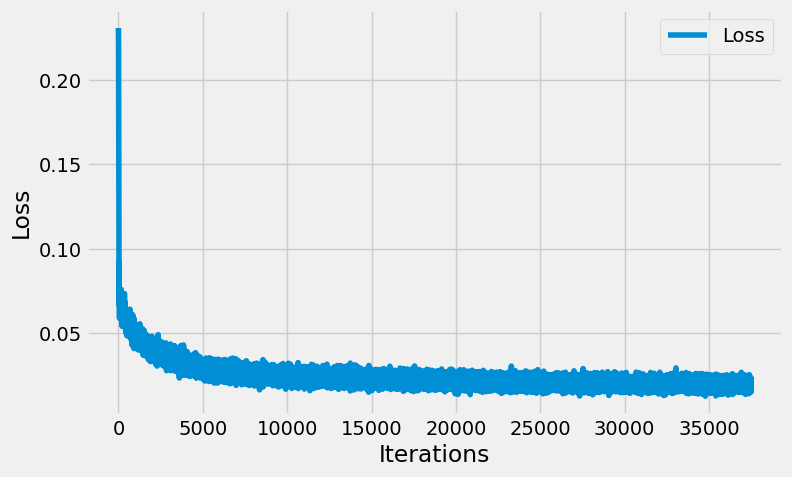

In [11]:
epochs = 20
outputs = []
losses = []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

for epoch in range(epochs):
    for images, _ in loader:
        images = images.view(-1, 28 * 28).to(device)
        
        reconstructed = model(images)
        loss = loss_function(reconstructed, images)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        losses.append(loss.item())
    
    outputs.append((epoch, images, reconstructed))
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.6f}")

plt.style.use('fivethirtyeight')
plt.figure(figsize=(8, 5))
plt.plot(losses, label='Loss')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.legend()
plt.show()

### Step 6: Visualizing Original and Reconstructed Images


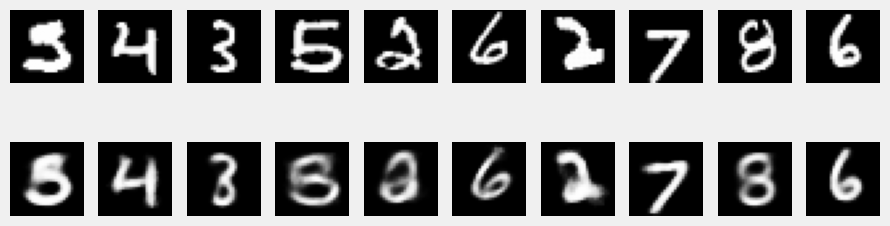

In [12]:
model.eval()
dataiter = iter(loader)
images, _ = next(dataiter)

images = images.view(-1, 28 * 28).to(device)
reconstructed = model(images)

fig, axes = plt.subplots(nrows=2, ncols=10, figsize=(10, 3))
for i in range(10):
    axes[0, i].imshow(images[i].cpu().detach().numpy().reshape(28, 28), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(reconstructed[i].cpu().detach().numpy().reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')
plt.show()